# Method: DeepLabV3 Wheat Segmentation

This method was adapted from the **CIFAR-10 demo shown in the lecture, Week 7 Deep Learning Part 1-2 on April 2**. We kept the same general PyTorch workflow from that example, like loading the data, defining the network, choosing a loss function and optimizer, training the model, and then testing the results. 

The main difference is that our project is a **segmentation** task instead of a classification task, so instead of predicting one label for the whole image, the model predicts a mask showing wheat and background.



## 1. Load and normalize the wheat dataset

Expected folder structure:

- project/
    - data/
        - train/
        - validation/
        - test/



In [1]:
# if you are running in a notebook
%matplotlib inline


In [2]:
import time
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models.segmentation import deeplabv3_resnet50


In [3]:
DATA_DIR = Path("data")
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "validation"
TEST_DIR = DATA_DIR / "test"

print("train exists     :", TRAIN_DIR.exists())
print("validation exists:", VAL_DIR.exists())
print("test exists      :", TEST_DIR.exists())


train exists     : True
validation exists: True
test exists      : True


In [4]:
class WheatSegmentationDataset(Dataset):
    def __init__(self, split_dir, image_size=(256, 256)):
        self.split_dir = Path(split_dir)
        self.image_size = image_size
        self.image_paths = sorted(
            [p for p in self.split_dir.glob("*.png") if not p.name.endswith("_mask.png")]
        )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        mask_path = image_path.with_name(image_path.stem + "_mask.png")

        image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.image_size, interpolation=cv2.INTER_LINEAR)
        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, self.image_size, interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype(np.float32)
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)


In [5]:
trainset = WheatSegmentationDataset(TRAIN_DIR, image_size=(256, 256))
valset = WheatSegmentationDataset(VAL_DIR, image_size=(256, 256))
testset = WheatSegmentationDataset(TEST_DIR, image_size=(256, 256))

trainloader = DataLoader(trainset, batch_size=4, shuffle=True, num_workers=0)
valloader = DataLoader(valset, batch_size=4, shuffle=False, num_workers=0)
testloader = DataLoader(testset, batch_size=4, shuffle=False, num_workers=0)

print("training images  :", len(trainset))
print("validation images:", len(valset))
print("test images      :", len(testset))


training images  : 142
validation images: 24
test images      : 24


Show some training images and masks, to check if its doing what we want it to.


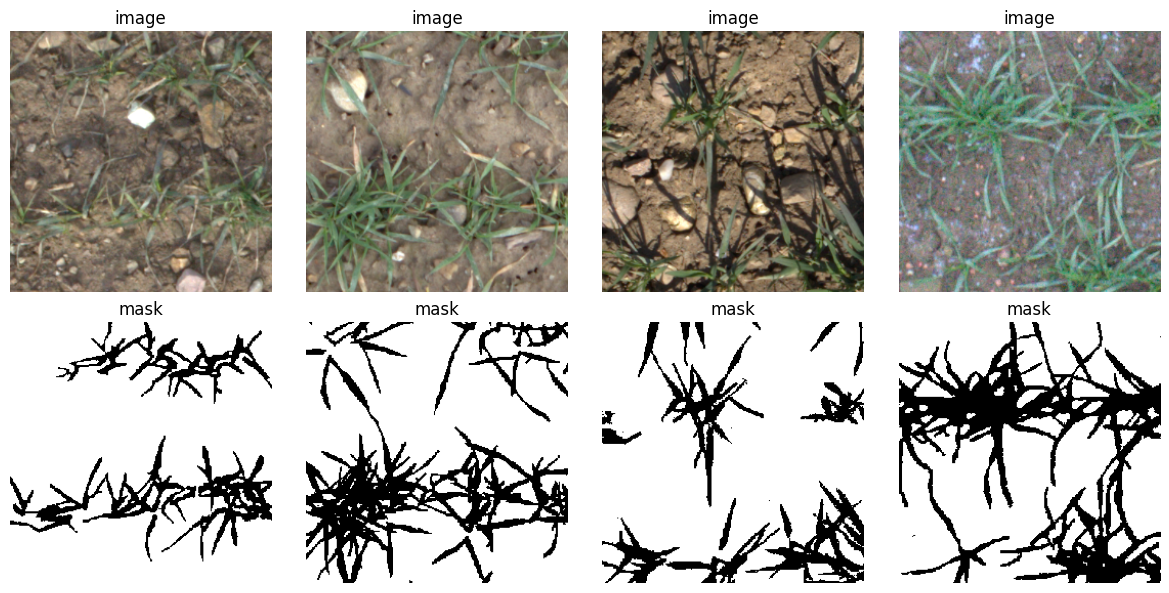

In [6]:
images, masks = next(iter(trainloader))

fig, ax = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    img = images[i].numpy().transpose(1, 2, 0)
    msk = masks[i, 0].numpy()

    ax[0, i].imshow(img)
    ax[0, i].set_title("image")
    ax[0, i].axis("off")

    ax[1, i].imshow(msk, cmap="gray")
    ax[1, i].set_title("mask")
    ax[1, i].axis("off")

plt.tight_layout()
plt.show()


## 2. Define the Neural Network

For this method, we are using **DeepLabV3** as the main model. Because our task only has **two classes** (wheat and background) we changed the last part of the network so it gives us **one output channel** instead of multiple classes. This lets the model produce a binary segmentation mask for each image.

In [7]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("using device:", device)


using device: mps


In [8]:
net = deeplabv3_resnet50(weights=None, weights_backbone=None)

in_channels = net.classifier[4].in_channels
net.classifier[4] = nn.Conv2d(in_channels, 1, kernel_size=1)

if net.aux_classifier is not None:
    aux_in_channels = net.aux_classifier[4].in_channels
    net.aux_classifier[4] = nn.Conv2d(aux_in_channels, 1, kernel_size=1)

net = net.to(device)
print(net.classifier)


DeepLabHead(
  (0): ASPP(
    (convs): ModuleList(
      (0): Sequential(
        (0): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (1): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(12, 12), dilation=(12, 12), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (2): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(24, 24), dilation=(24, 24), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (3): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(36, 36), dilation=(36, 36), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_

## 3. Define a loss function and optimizer

**BCEWithLogitsLoss** is used for binary segmentation and **Adam** is used for optimization.


In [9]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)


## 4. Helper Functions

While the model is training, we will keep checking how well it is doing using the **validation set**. The main results we want to watch are:

- **precision**  
- **recall**  
- **F1-score**  
- **IoU**

These help us see whether the model is improving as it trains, without using the test set too early.

In [10]:
def compute_metrics_from_logits(logits, masks, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(-1).cpu().numpy()
    masks = masks.view(-1).cpu().numpy()

    tp = np.sum((preds == 1) & (masks == 1))
    fp = np.sum((preds == 1) & (masks == 0))
    fn = np.sum((preds == 0) & (masks == 1))

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)

    return precision, recall, f1, iou


In [11]:
def train_one_epoch(net, loader, criterion, optimizer, device):
    net.train()
    running_loss = 0.0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = net(images)["out"]
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


def evaluate(net, loader, criterion, device):
    net.eval()
    running_loss = 0.0
    precisions, recalls, f1s, ious = [], [], [], []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = net(images)["out"]
            loss = criterion(outputs, masks)

            p, r, f1, iou = compute_metrics_from_logits(outputs, masks)

            running_loss += loss.item()
            precisions.append(p)
            recalls.append(r)
            f1s.append(f1)
            ious.append(iou)

    return {
        "loss": running_loss / len(loader),
        "precision": float(np.mean(precisions)),
        "recall": float(np.mean(recalls)),
        "f1": float(np.mean(f1s)),
        "iou": float(np.mean(ious)),
    }


## 5. Train in stages

We will train to:
- 5 total epochs
- 10 total epochs
- 20 total epochs

and check the **validation** results after each stage.


In [12]:
history = []
current_epoch = 0
total_training_time = 0.0


In [13]:
def train_until(target_epoch, net, trainloader, valloader, criterion, optimizer, device, history, current_epoch):
    stage_start = time.time()

    while current_epoch < target_epoch:
        current_epoch += 1

        train_loss = train_one_epoch(net, trainloader, criterion, optimizer, device)
        val_metrics = evaluate(net, valloader, criterion, device)

        row = {
            "epoch": current_epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_iou": val_metrics["iou"],
        }
        history.append(row)

        print(
            f"epoch {current_epoch} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_precision={val_metrics['precision']:.4f} | "
            f"val_recall={val_metrics['recall']:.4f} | "
            f"val_f1={val_metrics['f1']:.4f} | "
            f"val_iou={val_metrics['iou']:.4f}"
        )

    stage_time = time.time() - stage_start
    return current_epoch, stage_time


### Stage 1: train to 5 total epochs


In [14]:
current_epoch, stage_time = train_until(
    target_epoch=5,
    net=net,
    trainloader=trainloader,
    valloader=valloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    history=history,
    current_epoch=current_epoch,
)
total_training_time += stage_time
print(f"stage finished in {stage_time:.2f} seconds")


epoch 1 | train_loss=0.5944 | val_loss=0.6208 | val_precision=0.6884 | val_recall=1.0000 | val_f1=0.8028 | val_iou=0.6884
epoch 2 | train_loss=0.5130 | val_loss=0.5380 | val_precision=0.8683 | val_recall=0.6171 | val_f1=0.6924 | val_iou=0.5788
epoch 3 | train_loss=0.4426 | val_loss=0.9029 | val_precision=0.7599 | val_recall=0.7215 | val_f1=0.7380 | val_iou=0.5992
epoch 4 | train_loss=0.4082 | val_loss=1.5667 | val_precision=0.8252 | val_recall=0.6413 | val_f1=0.7138 | val_iou=0.5777
epoch 5 | train_loss=0.3941 | val_loss=0.4117 | val_precision=0.8311 | val_recall=0.8420 | val_f1=0.8317 | val_iou=0.7302
stage finished in 74.87 seconds


### Stage 2: continue training to 10 total epochs


In [15]:
current_epoch, stage_time = train_until(
    target_epoch=10,
    net=net,
    trainloader=trainloader,
    valloader=valloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    history=history,
    current_epoch=current_epoch,
)
total_training_time += stage_time
print(f"stage finished in {stage_time:.2f} seconds")


epoch 6 | train_loss=0.3882 | val_loss=0.4441 | val_precision=0.8357 | val_recall=0.8007 | val_f1=0.8084 | val_iou=0.6994
epoch 7 | train_loss=0.3734 | val_loss=0.4061 | val_precision=0.9103 | val_recall=0.7265 | val_f1=0.7897 | val_iou=0.6855
epoch 8 | train_loss=0.3550 | val_loss=0.6855 | val_precision=0.8304 | val_recall=0.7557 | val_f1=0.7890 | val_iou=0.6695
epoch 9 | train_loss=0.3506 | val_loss=0.5514 | val_precision=0.8583 | val_recall=0.7650 | val_f1=0.8056 | val_iou=0.6927
epoch 10 | train_loss=0.3502 | val_loss=0.3868 | val_precision=0.8186 | val_recall=0.9088 | val_f1=0.8606 | val_iou=0.7666
stage finished in 71.54 seconds


### Stage 3: continue training to 20 total epochs


In [16]:
current_epoch, stage_time = train_until(
    target_epoch=20,
    net=net,
    trainloader=trainloader,
    valloader=valloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    history=history,
    current_epoch=current_epoch,
)
total_training_time += stage_time
print(f"stage finished in {stage_time:.2f} seconds")
print(f"total training time so far: {total_training_time:.2f} seconds")


epoch 11 | train_loss=0.3436 | val_loss=0.4277 | val_precision=0.8571 | val_recall=0.8372 | val_f1=0.8450 | val_iou=0.7464
epoch 12 | train_loss=0.3226 | val_loss=0.3953 | val_precision=0.8659 | val_recall=0.8544 | val_f1=0.8588 | val_iou=0.7661
epoch 13 | train_loss=0.3170 | val_loss=0.4279 | val_precision=0.8444 | val_recall=0.8789 | val_f1=0.8609 | val_iou=0.7665
epoch 14 | train_loss=0.3057 | val_loss=0.5833 | val_precision=0.8896 | val_recall=0.8182 | val_f1=0.8492 | val_iou=0.7530
epoch 15 | train_loss=0.3040 | val_loss=0.4226 | val_precision=0.8625 | val_recall=0.8711 | val_f1=0.8664 | val_iou=0.7761
epoch 16 | train_loss=0.3055 | val_loss=0.4139 | val_precision=0.7998 | val_recall=0.9412 | val_f1=0.8602 | val_iou=0.7660
epoch 17 | train_loss=0.3052 | val_loss=0.3572 | val_precision=0.8565 | val_recall=0.8887 | val_f1=0.8721 | val_iou=0.7845
epoch 18 | train_loss=0.2877 | val_loss=0.3800 | val_precision=0.8843 | val_recall=0.8552 | val_f1=0.8688 | val_iou=0.7793
epoch 19 | train

## another 20 

Testing increases to see if we can get a closer mask to prediction

In [17]:
current_epoch, stage_time = train_until(
    target_epoch=30,
    net=net,
    trainloader=trainloader,
    valloader=valloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    history=history,
    current_epoch=current_epoch,
)
total_training_time += stage_time
print(f"stage finished in {stage_time:.2f} seconds")
print(f"total training time so far: {total_training_time:.2f} seconds")

epoch 21 | train_loss=0.2716 | val_loss=0.3467 | val_precision=0.9087 | val_recall=0.8428 | val_f1=0.8728 | val_iou=0.7850
epoch 22 | train_loss=0.2765 | val_loss=0.3741 | val_precision=0.8156 | val_recall=0.9517 | val_f1=0.8751 | val_iou=0.7877
epoch 23 | train_loss=0.2707 | val_loss=0.3627 | val_precision=0.9037 | val_recall=0.8440 | val_f1=0.8706 | val_iou=0.7823
epoch 24 | train_loss=0.2670 | val_loss=0.3020 | val_precision=0.8943 | val_recall=0.8883 | val_f1=0.8904 | val_iou=0.8092
epoch 25 | train_loss=0.2631 | val_loss=0.3438 | val_precision=0.8800 | val_recall=0.8769 | val_f1=0.8781 | val_iou=0.7919
epoch 26 | train_loss=0.2551 | val_loss=0.2986 | val_precision=0.8862 | val_recall=0.8955 | val_f1=0.8900 | val_iou=0.8096
epoch 27 | train_loss=0.2526 | val_loss=0.2903 | val_precision=0.8917 | val_recall=0.8999 | val_f1=0.8955 | val_iou=0.8177
epoch 28 | train_loss=0.2534 | val_loss=0.3294 | val_precision=0.8932 | val_recall=0.8793 | val_f1=0.8855 | val_iou=0.8030
epoch 29 | train

In [19]:
current_epoch, stage_time = train_until(
    target_epoch=40,
    net=net,
    trainloader=trainloader,
    valloader=valloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    history=history,
    current_epoch=current_epoch,
)
total_training_time += stage_time
print(f"stage finished in {stage_time:.2f} seconds")
print(f"total training time so far: {total_training_time:.2f} seconds")

stage finished in 0.00 seconds
total training time so far: 577.39 seconds


## Plot validation improvement


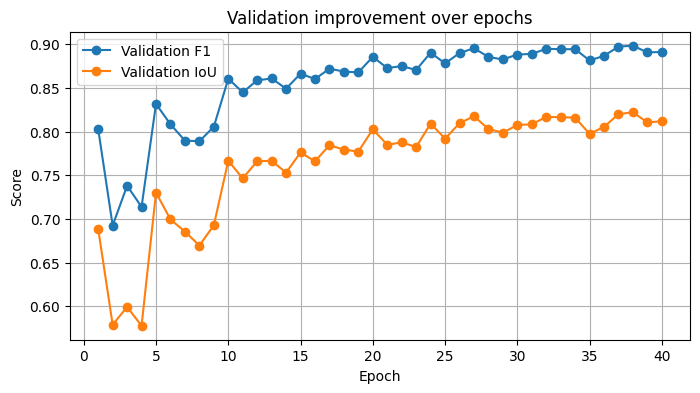

In [20]:
epochs = [row["epoch"] for row in history]
val_f1 = [row["val_f1"] for row in history]
val_iou = [row["val_iou"] for row in history]

plt.figure(figsize=(8, 4))
plt.plot(epochs, val_f1, marker="o", label="Validation F1")
plt.plot(epochs, val_iou, marker="o", label="Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation improvement over epochs")
plt.legend()
plt.grid(True)
plt.show()


## 6. Final test evaluation



In [21]:
test_metrics = evaluate(net, testloader, criterion, device)

print("final test summary")
for k, v in test_metrics.items():
    print(f"{k:>10}: {v:.4f}")


final test summary
      loss: 0.3044
 precision: 0.9270
    recall: 0.8639
        f1: 0.8937
       iou: 0.8098


## Visualise some final test predictions


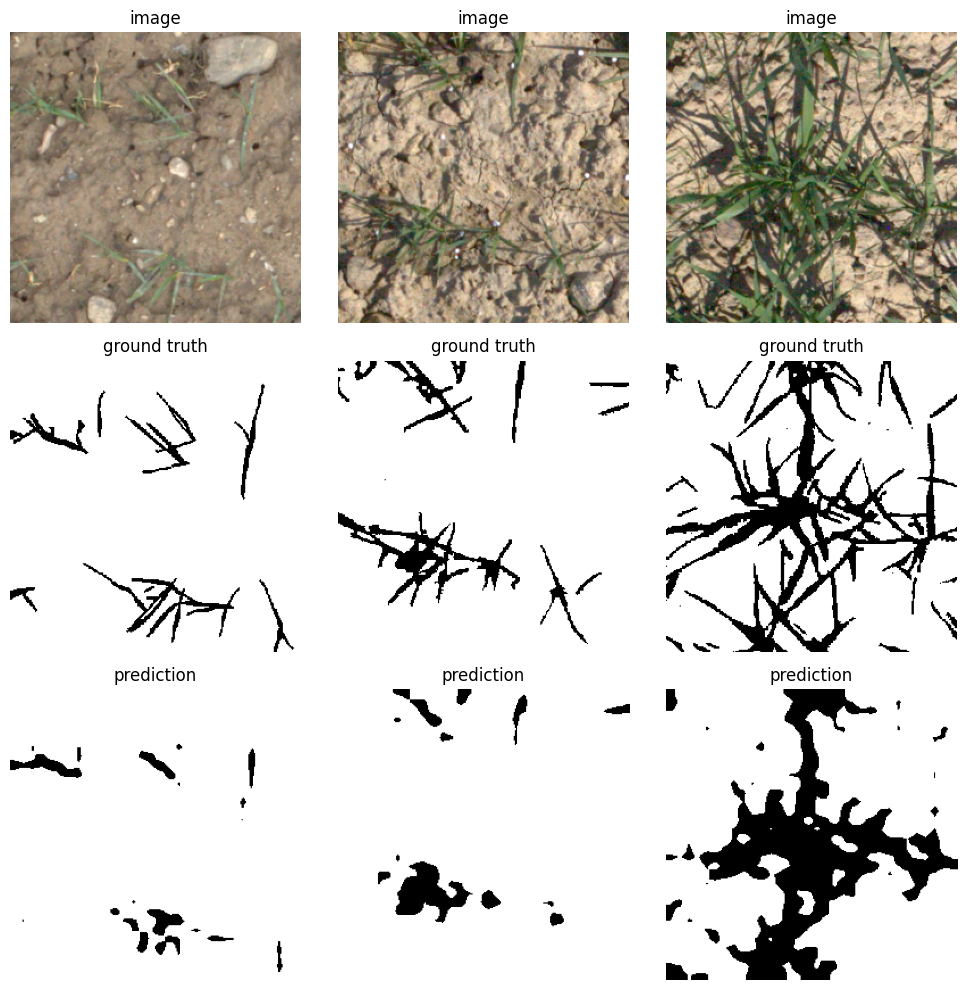

In [22]:
images, masks = next(iter(testloader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = net(images)["out"]
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).float()

fig, ax = plt.subplots(3, 3, figsize=(10, 10))

for i in range(3):
    img = images[i].cpu().numpy().transpose(1, 2, 0)
    gt = masks[i, 0].cpu().numpy()
    pred = preds[i, 0].cpu().numpy()

    ax[0, i].imshow(img)
    ax[0, i].set_title("image")
    ax[0, i].axis("off")

    ax[1, i].imshow(gt, cmap="gray")
    ax[1, i].set_title("ground truth")
    ax[1, i].axis("off")

    ax[2, i].imshow(pred, cmap="gray")
    ax[2, i].set_title("prediction")
    ax[2, i].axis("off")

plt.tight_layout()
plt.show()
